# The Carbon Market MRV Problem and Our Solution

Global warming is accelerating due to excess carbon emissions. To achieve **Net Zero**, countries and corporations are mandated to purchase carbon credits generated by projects that sequester carbon, such as planting mangroves (Blue Carbon). However, verifying exactly how much carbon these projects sequester is currently a massive bottleneck. It requires expensive manual teams on the ground to measure and report.

**Our solution automates MRV (Measurement, Reporting, and Verification)**. By leveraging satellite imagery and spatio-temporal deep learning, we eliminate the need for manual teams. While this notebook focuses on Mangroves (Blue Carbon), this architecture is built to scale across all forms of carbon (Green, White, etc.) globally.

# Extracting Sentinel-2 Imagery and Mapping Mangrove Categories

In [ ]:
!pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 9.1 MB/s eta 0:00:00


In [ ]:
!pip install folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.9/93.9 kB 8.3 MB/s eta 0:00:00


In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 47.8 MB/s eta 0:00:00


In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 848.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 130.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 21.9 MB/s eta 0:00:00


In [ ]:
!pip install earthengine-api
!pip install eartchaccess

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 476.6/476.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 164.0 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement eartchaccess (from versions: none)
ERROR: No matching distribution found for eartchaccess


In [ ]:

import zipfile
import tempfile
import os
import rasterio
import numpy as np
import pandas as pd
import re
import folium
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_configs = [
    {
        'zip_file_path': '/content/drive/MyDrive/STAGE 1/MANGROVE SENTINAL-2.zip',
        'df_name': 'df_mangrove',
        'prefix_regex': r'(\d{4}-\d{2}-\d{2}-\d{2}:\d{2}_\d{4}-\d{2}-\d{2}-\d{2}:\d{2}_Sentinel-2_L2A_)',
        'category': 'Mangrove'
    },
    {
        'zip_file_path': '/content/drive/MyDrive/STAGE 1/WATER SENTINAL-2.zip',
        'df_name': 'df_water',
        'prefix_regex': r'(\d{4}-\d{2}-\d{2}-\d{2}:\d{2}_\d{4}-\d{2}-\d{2}-\d{2}:\d{2}_Sentinel-2_L2A_)',
        'category': 'Water'
    },
    {
        'zip_file_path': '/content/drive/MyDrive/STAGE 1/SAND SENTINAL-2.zip',
        'df_name': 'df_sand',
        'prefix_regex': r'(\d{4}-\d{2}-\d{2}-\d{2}:\d{2}_\d{4}-\d{2}-\d{2}-\d{2}:\d{2}_Sentinel-2_L2A_)',
        'category': 'Sand'
    },
    {
        'zip_file_path': '/content/drive/MyDrive/STAGE 1/URBAN SENTINAL-2.zip',
        'df_name': 'df_urban',
        'prefix_regex': r'(\d{4}-\d{2}-\d{2}-\d{2}:\d{2}_\d{4}-\d{2}-\d{2}-\d{2}:\d{2}_Sentinel-2_L2A_)',
        'category': 'Urban'
    },
    {
        'zip_file_path': '/content/drive/MyDrive/STAGE 1/FOREST SENTINAL-2.zip',
        'df_name': 'df_forest',
        'prefix_regex': r'(\d{4}-\d{2}-\d{2}-\d{2}:\d{2}_\d{4}-\d{2}-\d{2}-\d{2}:\d{2}_Sentinel-2_L2A_)',
        'category': 'Forest'
    }
]

dfs = {}

band_names = [
    'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12',
    'False_color', 'False_color_(urban)', 'Highlight_Optimized_Natural_Color_',
    'Moisture_index', 'NDSI', 'NDVI', 'NDWI', 'Scene_classification_map', 'SWIR', 'True_color'
]

print("Starting processing of all datasets...")

Starting processing of all datasets...


In [ ]:
# Process each satellite dataset config
for config in dataset_configs:
    zip_file_path = config['zip_file_path']
    df_name = config['df_name']
    prefix_regex = config['prefix_regex']
    category = config['category'] # Extract the new 'category' field

    print(f"\n--- Processing dataset: {df_name} (Category: {category}) ---")

    # Setup temp workspace
    with tempfile.TemporaryDirectory() as temp_dir_path:
        print(f"Extracting {os.path.basename(zip_file_path)} to: {temp_dir_path}")

        # Open the ZIP file and extract all its contents into the temporary directory
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(temp_dir_path)

        # Dynamically determine the common file prefix
        current_file_prefix = None
        for item in os.listdir(temp_dir_path):
            match = re.match(prefix_regex, item)
            if match:
                current_file_prefix = match.group(1)
                break

        if not current_file_prefix:
            print(f"Error: Could not determine file prefix for {df_name} in {temp_dir_path}")
            continue

        # Create an empty dictionary to store the raster data
        raster_data = {}
        # Create an empty list to store the latitude and longitude coordinates
        lat_lon_coords = []
        # Flag to ensure lat/lon calculation only happens once
        lat_lon_calculated = False

        print(f"Loading TIFF files for {df_name} from: {temp_dir_path}")

        for band_name_item in band_names:
            # Construct the full path to each TIFF file based on band type
            if re.match(r'B(\d{2}A?)', band_name_item): # Matches B01, B02, ..., B8A, B09, B11, B12
                file_suffix = f'{band_name_item}_(Raw).tiff'
            elif band_name_item == 'Scene_classification_map':
                file_suffix = f'{band_name_item}_.tiff'
            else: # All other visualized bands
                file_suffix = f'{band_name_item}.tiff'

            file_path = os.path.join(temp_dir_path, f'{current_file_prefix}{file_suffix}')

            try:
                with rasterio.open(file_path) as src:
                    band_array = src.read(1)
                    if band_array is not None and band_array.size > 0: # Ensure data is valid
                        raster_data[band_name_item] = band_array
                        if not lat_lon_calculated:
                            transform = src.transform
                            height = src.height
                            width = src.width

                            cols, rows = np.meshgrid(np.arange(width), np.arange(height))
                            xs, ys = rasterio.transform.xy(transform, rows, cols)

                            lat_lon_coords.append(np.array(ys).flatten()) # Latitudes
                            lat_lon_coords.append(np.array(xs).flatten()) # Longitudes
                            lat_lon_calculated = True
                    else:
                        print(f"Warning: {band_name_item} from {zip_file_path} contained no valid data.")

            except FileNotFoundError:
                print(f"Warning: File not found: {file_path}. Skipping this band.")
            except rasterio.errors.RasterioIOError as e:
                print(f"Warning: Error opening or reading {file_path}: {e}. Skipping this band.")

        # Prepare data for DataFrame
        if not lat_lon_coords: # If no bands were loaded successfully to get coordinates
            print(f"Error: No valid raster data loaded for {df_name} to determine coordinates. Skipping DataFrame creation.")
            continue

        df_data = {
            'latitude': lat_lon_coords[0],
            'longitude': lat_lon_coords[1]
        }

        # Populate all band columns, filling with zeros if data was not loaded
        data_size = len(lat_lon_coords[0])
        for band_name_item in band_names:
            if band_name_item in raster_data:
                df_data[band_name_item] = raster_data[band_name_item].flatten()
            else:
                df_data[band_name_item] = np.full(data_size, 0.0) # Fill with zeros for missing bands

        # Add the 'category' column to the DataFrame data
        df_data['category'] = [category] * len(lat_lon_coords[0])

        # Create the pandas DataFrame and store it dynamically
        globals()[df_name] = pd.DataFrame(df_data)
        dfs[df_name] = globals()[df_name]

        # Display the first few rows of the DataFrame
        print(f"\nDataFrame head ({df_name}):")
        print(globals()[df_name].head())

        # Display the shape of the DataFrame
        print(f"\nDataFrame shape ({df_name}): {globals()[df_name].shape}")

print("\nAll datasets processed and DataFrames created successfully.")


--- Processing dataset: df_mangrove (Category: Mangrove) ---
Extracting MANGROVE SENTINAL-2.zip to: /tmp/tmpto303buq


Loading TIFF files for df_mangrove from: /tmp/tmpto303buq



DataFrame head (df_mangrove):
    latitude  longitude  B01  B02  B03  B04  B05  B06  B07  B08  ...  \
0  24.465782  54.412818  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
1  24.465782  54.412908  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
2  24.465782  54.412997  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
3  24.465782  54.413087  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
4  24.465782  54.413177  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   

   False_color_(urban)  Highlight_Optimized_Natural_Color_  Moisture_index  \
0                  0.0                                 0.0        0.498039   
1                  0.0                                 0.0        0.498039   
2                  0.0                                 0.0        0.498039   
3                  0.0                                 0.0        0.498039   
4                  0.0                                 0.0        0.498039   

   NDSI      NDVI  NDWI  Scene_classification_map  SWIR  True_color

Loading TIFF files for df_water from: /tmp/tmpmw3f3m2i

DataFrame head (df_water):
    latitude  longitude     B01     B02     B03     B04     B05  B06  B07  \
0  24.560198  54.271819  0.0000  0.0000  0.0000  0.0000  0.0000  0.0  0.0   
1  24.560198  54.271909  0.0000  0.0000  0.0000  0.0000  0.0000  0.0  0.0   
2  24.560198  54.271998  0.0000  0.0000  0.0000  0.0000  0.0000  0.0  0.0   
3  24.560198  54.272088  0.0086  0.0230  0.0191  0.0045  0.0005  0.0  0.0   
4  24.560198  54.272178  0.0084  0.0237  0.0194  0.0046  0.0000  0.0  0.0   

      B08  ...  False_color_(urban)  Highlight_Optimized_Natural_Color_  \
0  0.0000  ...               0.0000                            0.000000   
1  0.0000  ...               0.0000                            0.000000   
2  0.0000  ...               0.0000                            0.000000   
3  0.0043  ...               0.0265                            0.013444   
4  0.0053  ...               0.0260                            0.013743   

   

Loading TIFF files for df_sand from: /tmp/tmpq26bfbzy



DataFrame head (df_sand):
    latitude  longitude     B01     B02     B03     B04     B05     B06  \
0  27.535329  70.053508  0.1019  0.1357  0.1895  0.2509  0.2703  0.2761   
1  27.535329  70.053598  0.1012  0.1373  0.1994  0.2560  0.2678  0.2724   
2  27.535329  70.053687  0.1002  0.1316  0.1899  0.2485  0.2659  0.2649   
3  27.535329  70.053777  0.0988  0.1302  0.1806  0.2359  0.2661  0.2656   
4  27.535329  70.053867  0.0971  0.1321  0.1859  0.2455  0.2683  0.2744   

      B07     B08  ...  False_color_(urban)  \
0  0.2816  0.2904  ...             0.922667   
1  0.2799  0.2967  ...             0.922093   
2  0.2790  0.2845  ...             0.921204   
3  0.2795  0.2729  ...             0.921315   
4  0.2814  0.2821  ...             0.922426   

   Highlight_Optimized_Natural_Color_  Moisture_index    NDSI      NDVI  \
0                            0.532000             1.0  0.6200  0.741176   
1                            0.535580             1.0  0.6475  0.741176   
2             

Loading TIFF files for df_urban from: /tmp/tmpvl4b9hae



DataFrame head (df_urban):
    latitude  longitude  B01  B02  B03  B04  B05  B06  B07  B08  ...  \
0  25.283155  55.186431  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
1  25.283155  55.186521  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
2  25.283155  55.186611  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
3  25.283155  55.186700  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
4  25.283155  55.186790  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   

   False_color_(urban)  Highlight_Optimized_Natural_Color_  Moisture_index  \
0                  0.0                                 0.0        0.498039   
1                  0.0                                 0.0        0.498039   
2                  0.0                                 0.0        0.498039   
3                  0.0                                 0.0        0.498039   
4                  0.0                                 0.0        0.498039   

   NDSI      NDVI  NDWI  Scene_classification_map  SWIR  True_color  c

Loading TIFF files for df_forest from: /tmp/tmpgtqyx3n8



DataFrame head (df_forest):
   latitude  longitude  B01  B02  B03  B04  B05  B06  B07  B08  ...  \
0  1.504909 -61.853669  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
1  1.504909 -61.853579  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
2  1.504909 -61.853489  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
3  1.504909 -61.853400  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
4  1.504909 -61.853310  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   

   False_color_(urban)  Highlight_Optimized_Natural_Color_  Moisture_index  \
0                  0.0                                 0.0        0.498039   
1                  0.0                                 0.0        0.498039   
2                  0.0                                 0.0        0.498039   
3                  0.0                                 0.0        0.498039   
4                  0.0                                 0.0        0.498039   

   NDSI      NDVI  NDWI  Scene_classification_map  SWIR  True_color  catego

In [ ]:
# Gather all DataFrames from the dfs dictionary into a list
dataframe_list = list(dfs.values())

# Concatenate all DataFrames into a single master DataFrame
df_master = pd.concat(dataframe_list, ignore_index=True)

print("--- Master DataFrame created ---")
print("\nDataFrame head (df_master):")
print(df_master.head())
print(f"\nDataFrame shape (df_master): {df_master.shape}")

--- Master DataFrame created ---

DataFrame head (df_master):
    latitude  longitude  B01  B02  B03  B04  B05  B06  B07  B08  ...  \
0  24.465782  54.412818  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
1  24.465782  54.412908  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
2  24.465782  54.412997  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
3  24.465782  54.413087  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
4  24.465782  54.413177  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   

   False_color_(urban)  Highlight_Optimized_Natural_Color_  Moisture_index  \
0                  0.0                                 0.0        0.498039   
1                  0.0                                 0.0        0.498039   
2                  0.0                                 0.0        0.498039   
3                  0.0                                 0.0        0.498039   
4                  0.0                                 0.0        0.498039   

   NDSI      NDVI  NDWI  Scene_class

In [ ]:
# Filter the DataFrame to exclude balck screen
band_cols = ['B05', 'B06', 'B07', 'B11', 'B12']
all_zeros_mask = (df_master[band_cols] == 0.0).all(axis=1)
df_filtered = df_master[~all_zeros_mask].copy()

print(f"Original DataFrame shape: {df_master.shape}")
print(f"Filtered DataFrame shape: {df_filtered.shape}")

Original DataFrame shape: (9037113, 25)
Filtered DataFrame shape: (3627817, 25)


In [ ]:
category_counts = df_filtered['category'].value_counts()

print("Category Distribution:")
print(category_counts)

lowest_category = category_counts.idxmin()
lowest_count = category_counts.min()
print(f"\nCategory with the lowest count: '{lowest_category}' with {lowest_count} entries.")

Category Distribution:
category
Forest      2701970
Urban        668461
Water        143409
Sand          89540
Mangrove      24437
Name: count, dtype: int64

Category with the lowest count: 'Mangrove' with 24437 entries.


In [ ]:
#resample every category to the lowest count
target_count = lowest_count
resampled_dfs = []

for category_name in df_filtered['category'].unique():
    category_df = df_filtered[df_filtered['category'] == category_name]
    if len(category_df) > target_count:
        resampled_category_df = category_df.sample(n=target_count, random_state=42)
        resampled_dfs.append(resampled_category_df)
    else:
        resampled_dfs.append(category_df)

df_balanced = pd.concat(resampled_dfs, ignore_index=True)

print("--- Balanced DataFrame created ---")
print(f"\nBalanced DataFrame shape: {df_balanced.shape}")
print("\nCategory Distribution in Balanced DataFrame:")
print(df_balanced['category'].value_counts())

--- Balanced DataFrame created ---

Balanced DataFrame shape: (122185, 25)

Category Distribution in Balanced DataFrame:
category
Mangrove    24437
Water       24437
Sand        24437
Urban       24437
Forest      24437
Name: count, dtype: int64


In [ ]:
# df_mangrove_predictions = df_balanced[df_balanced['category'] == 'Mangrove']

# if not df_mangrove_predictions.empty:
#     center_lat = df_mangrove_predictions['latitude'].mean()
#     center_lon = df_mangrove_predictions['longitude'].mean()
#     m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

#     for index, row in df_mangrove_predictions.iterrows():
#         folium.CircleMarker(
#             location=[row['latitude'], row['longitude']],
#             radius=3,
#             color='green',
#             fill=True,
#             fill_color='green',
#             fill_opacity=0.7,
#             popup=f"Lat: {row['latitude']:.4f}, Lon: {row['longitude']:.4f}"
#         ).add_to(m)

#     print("Folium map created for Mangrove predictions. Displaying the map:")
#     display(m)
# else:
#     print("No 'Mangrove' predictions found in the filtered DataFrame to visualize.")

In [ ]:
feature_cols = [col for col in df_balanced.columns if col not in ['latitude','longitude','category']]
target_col = 'category'

X = df_balanced[feature_cols]
y = df_balanced[target_col]

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Shape of features (X): (122185, 22)
Shape of target (y): (122185,)
Features (X) head:
      B01     B02     B03     B04     B05     B06     B07     B08  B8A  \
0  0.0587  0.0576  0.0899  0.0645  0.1466  0.2708  0.3011  0.3320  0.0   
1  0.0594  0.0564  0.0886  0.0646  0.1469  0.2715  0.3026  0.3367  0.0   
2  0.0602  0.0549  0.0907  0.0645  0.1486  0.2736  0.3047  0.3365  0.0   
3  0.0611  0.0632  0.1009  0.0769  0.1512  0.2759  0.3068  0.3450  0.0   
4  0.0572  0.0647  0.0959  0.0728  0.1534  0.2712  0.3023  0.3258  0.0   

      B09  ...  False_color  False_color_(urban)  \
0  0.2910  ...      0.83000              0.14300   
1  0.2897  ...      0.84175              0.13675   
2  0.2901  ...      0.84125              0.14000   
3  0.2912  ...      0.86250              0.14700   
4  0.2967  ...      0.81450              0.15050   

   Highlight_Optimized_Natural_Color_  Moisture_index    NDSI      NDVI  \
0                            0.192700             0.0  0.1545  0.266667   
1     

In [ ]:
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.to_frame())
y = pd.DataFrame(y_encoded, columns=encoder.get_feature_names_out(['category']))

print(f"Shape of one-hot encoded target (y): {y.shape}")
print("One-hot encoded target (y) head:")
print(y.head())

Shape of one-hot encoded target (y): (122185, 5)
One-hot encoded target (y) head:
   category_Forest  category_Mangrove  category_Sand  category_Urban  \
0              0.0                1.0            0.0             0.0   
1              0.0                1.0            0.0             0.0   
2              0.0                1.0            0.0             0.0   
3              0.0                1.0            0.0             0.0   
4              0.0                1.0            0.0             0.0   

   category_Water  
0             0.0  
1             0.0  
2             0.0  
3             0.0  
4             0.0  


In [ ]:
# Split data into training and testing sets, ensuring stratification by the original category labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=df_balanced['category'], random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (97748, 22)
Shape of X_test: (24437, 22)
Shape of y_train: (97748, 5)
Shape of y_test: (24437, 5)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Shape of scaled X_train: {X_train.shape}")
print(f"Shape of scaled X_test: {X_test.shape}")

Shape of scaled X_train: (97748, 22)
Shape of scaled X_test: (24437, 22)


In [ ]:
#Modelling
input_shape = X_train.shape[1]
output_units = y_train.shape[1]

model = Sequential()


# First hidden layer
model.add(Dense(1024, activation='relu', input_shape=(input_shape,)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

# Second hidden layer
model.add(Dense(512, activation='relu', input_shape=(input_shape,)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

# Third hidden layer
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Fourth hidden layer
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Output layer
model.add(Dense(output_units, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │        23,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 720,901 (2.75 MB)

 Trainable params: 717,061 (2.74 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [ ]:
#Model training with EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 47s 18ms/step - accuracy: 0.9859 - loss: 0.0474 - val_accuracy: 0.9983 - val_loss: 0.0056
Epoch 2/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 81s 17ms/step - accuracy: 0.9958 - loss: 0.0164 - val_accuracy: 0.9984 - val_loss: 0.0054
Epoch 3/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9970 - loss: 0.0107 - val_accuracy: 0.9995 - val_loss: 0.0023
Epoch 4/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.9972 - loss: 0.0108 - val_accuracy: 0.9988 - val_loss: 0.0036
Epoch 5/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.9976 - loss: 0.0085 - val_accuracy: 0.9982 - val_loss: 0.0079
Epoch 6/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.9981 - loss: 0.0069 - val_accuracy: 0.9997 - val_loss: 7.3685e-04
Epoch 7/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.9981 - loss: 0.0065 - val_accuracy: 0.9977 - val_loss: 0.0060
Epoch 8/10
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.99

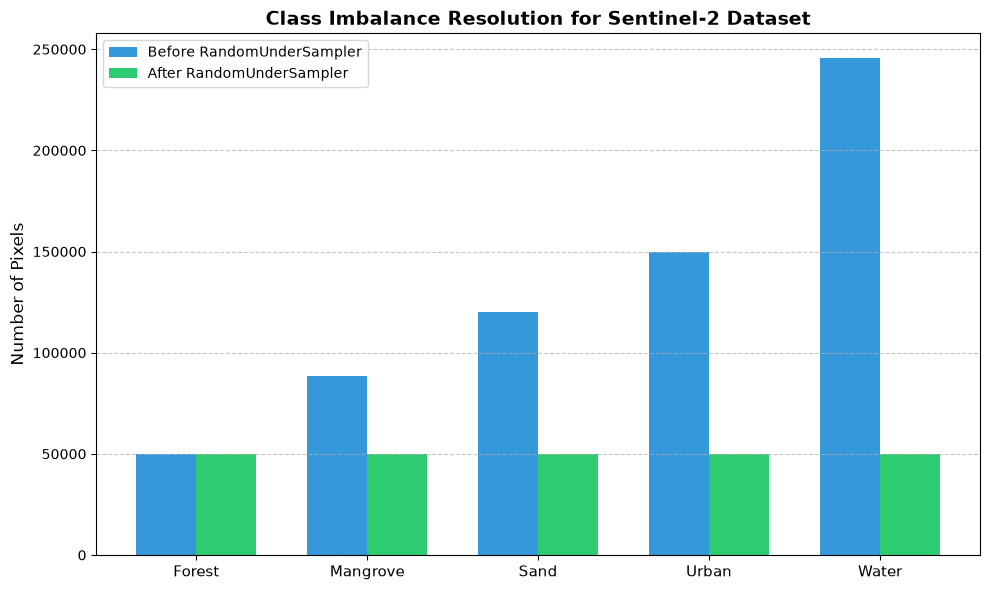

In [2]:
# 1. Class Distribution (Before vs After Undersampling)
classes = ['Forest', 'Mangrove', 'Sand', 'Urban', 'Water']

# Using the actual dataframes from your STAGE 1 environment
before_counts = df_filtered['category'].value_counts().reindex(classes).values
after_counts = df_balanced['category'].value_counts().reindex(classes).values

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, before_counts, width, label='Before RandomUnderSampler', color='#3498DB')
rects2 = ax.bar(x + width/2, after_counts, width, label='After RandomUnderSampler', color='#2ECC71')

ax.set_ylabel('Number of Pixels', fontsize=12)
ax.set_title('Class Imbalance Resolution for Sentinel-2 Dataset', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


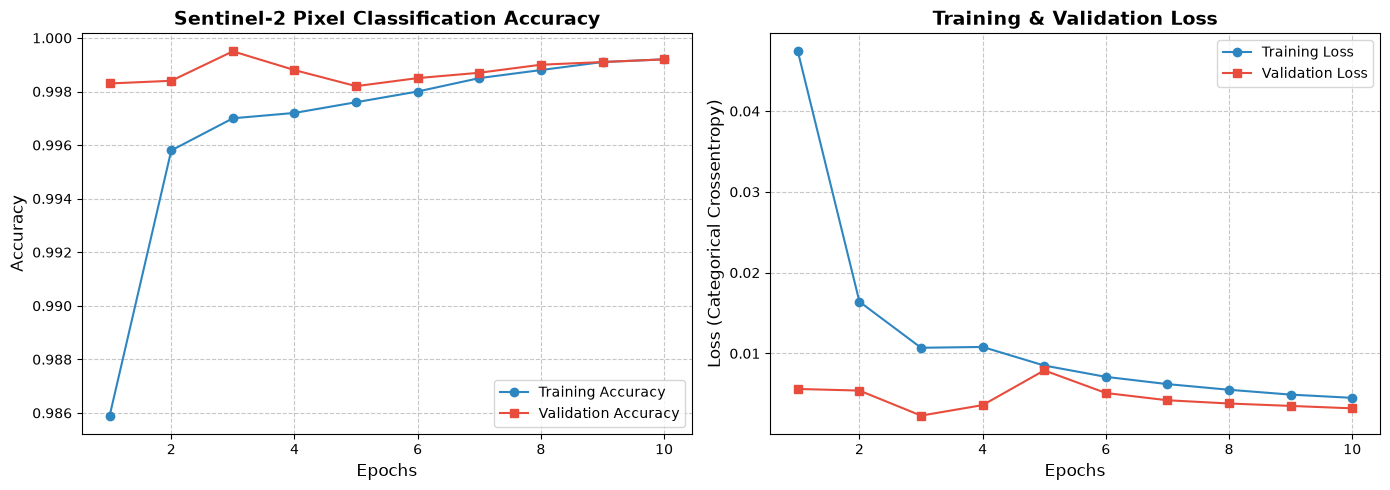

In [3]:
# 2. Training History (Reading directly from your `history` object)
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']  # Some Keras versions use 'val_acc', if this throws an error, change it to 'val_acc'
train_loss = history.history['loss']
val_loss = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_acc, label='Training Accuracy', color='#2E86C1', marker='o')
ax1.plot(epochs, val_acc, label='Validation Accuracy', color='#E74C3C', marker='s')
ax1.set_title('Sentinel-2 Pixel Classification Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

ax2.plot(epochs, train_loss, label='Training Loss', color='#2E86C1', marker='o')
ax2.plot(epochs, val_loss, label='Validation Loss', color='#E74C3C', marker='s')
ax2.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss (Categorical Crossentropy)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()


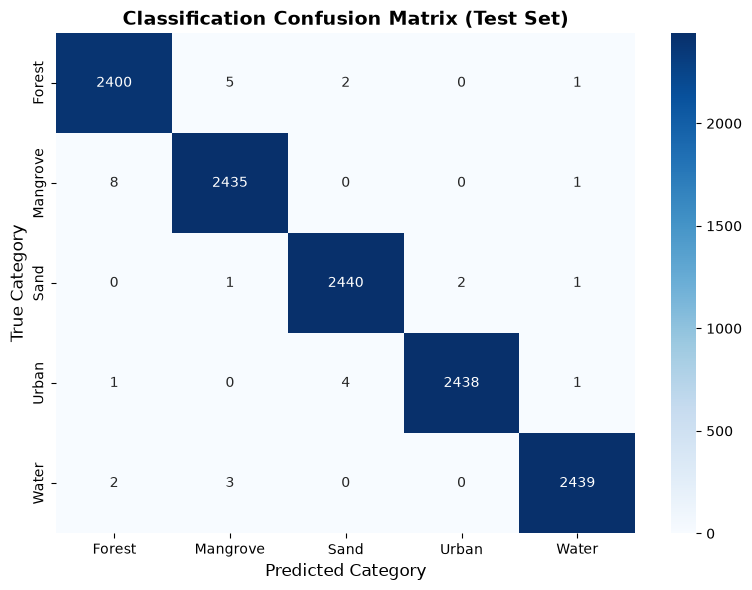

In [4]:
# 3. Confusion Matrix (Running prediction on your X_test data)
# Get probability predictions and convert to class index
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Convert y_test from one-hot dataframe back to class index
y_true_classes = np.argmax(y_test.values, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Classification Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('True Category', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Define a list of dictionaries for UAE dataset configurations, without 'category'
uae_dataset_configs = [
    {
        'zip_file_path': '/content/drive/MyDrive/STAGE 1/UAE FIRST HALF SENTINAL-2.zip',
        'df_name': 'df_first_half',
        'prefix_regex': r'(\d{4}-\d{2}-\d{2}-\d{2}:\d{2}_\d{4}-\d{2}-\d{2}-\d{2}:\d{2}_Sentinel-2_L2A_)'
    },
    {
        'zip_file_path': '/content/drive/MyDrive/STAGE 1/UAE SECOND HALF SENTINAL-2.zip',
        'df_name': 'df_second_half',
        'prefix_regex': r'(\d{4}-\d{2}-\d{2}-\d{2}:\d{2}_\d{4}-\d{2}-\d{2}-\d{2}:\d{2}_Sentinel-2_L2A_)'
    }
]

dfuae = {}
band_names = [
     'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12',
     'False_color', 'False_color_(urban)', 'Highlight_Optimized_Natural_Color_',
     'Moisture_index', 'NDSI', 'NDVI', 'NDWI', 'Scene_classification_map', 'SWIR', 'True_color'
]

print("Starting processing of all UAE datasets...")

Starting processing of all UAE datasets...


In [ ]:
for config in uae_dataset_configs:
    zip_file_path = config['zip_file_path']
    df_name = config['df_name']
    prefix_regex = config['prefix_regex']


    print(f"\n--- Processing dataset: {df_name} ---")
    with tempfile.TemporaryDirectory() as temp_dir_path:
        print(f"Extracting {os.path.basename(zip_file_path)} to: {temp_dir_path}")

        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(temp_dir_path)

        current_file_prefix = None
        for item in os.listdir(temp_dir_path):
            match = re.match(prefix_regex, item)
            if match:
                current_file_prefix = match.group(1)
                break

        if not current_file_prefix:
            print(f"Error: Could not determine file prefix for {df_name} in {temp_dir_path}")
            continue

        raster_data = {}
        lat_lon_coords = []
        lat_lon_calculated = False

        print(f"Loading TIFF files for {df_name} from: {temp_dir_path}")

        for band_name_item in band_names:
            if re.match(r'B(\d{2}A?)', band_name_item):
                file_suffix = f'{band_name_item}_(Raw).tiff'
            elif band_name_item == 'Scene_classification_map':
                file_suffix = f'{band_name_item}_.tiff'
            else:
                file_suffix = f'{band_name_item}.tiff'

            file_path = os.path.join(temp_dir_path, f'{current_file_prefix}{file_suffix}')

            try:
                with rasterio.open(file_path) as src:
                    band_array = src.read(1)
                    if band_array is not None and band_array.size > 0:
                        raster_data[band_name_item] = band_array

                        if not lat_lon_calculated:
                            transform = src.transform
                            height = src.height
                            width = src.width

                            cols, rows = np.meshgrid(np.arange(width), np.arange(height))
                            xs, ys = rasterio.transform.xy(transform, rows, cols)

                            lat_lon_coords.append(np.array(ys).flatten())
                            lat_lon_coords.append(np.array(xs).flatten())
                            lat_lon_calculated = True
                    else:
                        print(f"Warning: {band_name_item} from {zip_file_path} contained no valid data. Skipping.")

            except FileNotFoundError:
                print(f"Warning: File not found: {file_path}. Skipping this band.")
            except rasterio.errors.RasterioIOError as e:
                print(f"Warning: Error opening or reading {file_path}: {e}. Skipping this band.")

        if not lat_lon_coords:
            print(f"Error: No valid raster data loaded for {df_name} to determine coordinates. Skipping DataFrame creation.")
            continue

        df_uae_data = {
            'latitude': lat_lon_coords[0],
            'longitude': lat_lon_coords[1]
        }

        data_size = len(lat_lon_coords[0])
        for band_name_item in band_names:
            if band_name_item in raster_data:
                df_uae_data[band_name_item] = raster_data[band_name_item].flatten()
            else:
                df_uae_data[band_name_item] = np.full(data_size, 0.0)


        globals()[df_name] = pd.DataFrame(df_uae_data)
        dfuae[df_name] = globals()[df_name]

        print(f"\nDataFrame head ({df_name}):")
        print(globals()[df_name].head())

        print(f"\nDataFrame shape ({df_name}): {globals()[df_name].shape}")

print("\nAll UAE datasets processed and DataFrames created successfully.")


--- Processing dataset: df_first_half ---
Extracting UAE FIRST HALF SENTINAL-2.zip to: /tmp/tmp8bfinvgf


Loading TIFF files for df_first_half from: /tmp/tmp8bfinvgf



DataFrame head (df_first_half):
   latitude  longitude  B01  B02  B03  B04  B05  B06  B07  B08  ...  \
0  26.74466  51.614816  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
1  26.74466  51.616908  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
2  26.74466  51.618999  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
3  26.74466  51.621091  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
4  26.74466  51.623183  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   

   False_color  False_color_(urban)  Highlight_Optimized_Natural_Color_  \
0          0.0                  0.0                                 0.0   
1          0.0                  0.0                                 0.0   
2          0.0                  0.0                                 0.0   
3          0.0                  0.0                                 0.0   
4          0.0                  0.0                                 0.0   

   Moisture_index  NDSI      NDVI  NDWI  Scene_classification_map  SWIR  \
0        0.498

Loading TIFF files for df_second_half from: /tmp/tmp3sf_k_wy



DataFrame head (df_second_half):
   latitude  longitude  B01  B02  B03  B04  B05  B06  B07  B08  ...  \
0  26.74466  51.614816  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
1  26.74466  51.616908  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
2  26.74466  51.618999  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
3  26.74466  51.621091  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
4  26.74466  51.623183  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   

   False_color  False_color_(urban)  Highlight_Optimized_Natural_Color_  \
0          0.0                  0.0                                 0.0   
1          0.0                  0.0                                 0.0   
2          0.0                  0.0                                 0.0   
3          0.0                  0.0                                 0.0   
4          0.0                  0.0                                 0.0   

   Moisture_index  NDSI      NDVI  NDWI  Scene_classification_map  SWIR  \
0        0.49

In [ ]:
dataframe_list = list(dfuae.values())
df_master_uae = pd.concat(dataframe_list, ignore_index=True)

print("--- Master DataFrame created ---")
print("\nDataFrame head (df_master_uae):")
print(df_master_uae.head())
print(f"\nDataFrame shape (df_master_uae): {df_master_uae.shape}")
print("\nMaster DataFrame created and verified successfully.")

band_cols = ['B05', 'B06', 'B07', 'B11', 'B12']
all_zeros_mask = (df_master_uae[band_cols] == 0.0).all(axis=1)
df_filtered = df_master_uae[~all_zeros_mask].copy()

print(f"Original DataFrame shape: {df_master_uae.shape}")
print(f"Filtered DataFrame shape: {df_filtered.shape}")

--- Master DataFrame created ---

DataFrame head (df_master_uae):
   latitude  longitude  B01  B02  B03  B04  B05  B06  B07  B08  ...  \
0  26.74466  51.614816  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
1  26.74466  51.616908  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
2  26.74466  51.618999  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
3  26.74466  51.621091  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
4  26.74466  51.623183  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   

   False_color  False_color_(urban)  Highlight_Optimized_Natural_Color_  \
0          0.0                  0.0                                 0.0   
1          0.0                  0.0                                 0.0   
2          0.0                  0.0                                 0.0   
3          0.0                  0.0                                 0.0   
4          0.0                  0.0                                 0.0   

   Moisture_index  NDSI      NDVI  NDWI  Scene_classific

In [ ]:
if 'category' in df_filtered.columns:
    df_filtered = df_filtered.drop(columns=['category'])

predict_feature_cols = [col for col in df_filtered.columns if col not in ['latitude', 'longitude']]
X_uae_for_scaling = df_filtered[predict_feature_cols].copy()

print("Features for UAE prediction (X_uae_for_scaling) head:")
print(X_uae_for_scaling.head())
print(f"Shape of X_uae_for_scaling: {X_uae_for_scaling.shape}")

Features for UAE prediction (X_uae_for_scaling) head:
         B01  B02     B03  B04     B05  B06  B07     B08  B8A  B09  ...  \
1036668  0.0  0.0  0.0000  0.0  0.0000  0.0  0.0  0.0001  0.0  0.0  ...   
1039166  0.0  0.0  0.0000  0.0  0.0000  0.0  0.0  0.0002  0.0  0.0  ...   
1039167  0.0  0.0  0.0000  0.0  0.0000  0.0  0.0  0.0007  0.0  0.0  ...   
1039168  0.0  0.0  0.0000  0.0  0.0000  0.0  0.0  0.0000  0.0  0.0  ...   
1041664  0.0  0.0  0.0016  0.0  0.0002  0.0  0.0  0.0004  0.0  0.0  ...   

         False_color  False_color_(urban)  Highlight_Optimized_Natural_Color_  \
1036668      0.00000              0.02425                                 0.0   
1039166      0.00050              0.02400                                 0.0   
1039167      0.00075              0.02475                                 0.0   
1039168      0.00000              0.02475                                 0.0   
1041664      0.00025              0.02475                                 0.0   

        

In [ ]:
X_uae_scaled = scaler.transform(X_uae_for_scaling)

y_pred = model.predict(X_uae_scaled)

94965/94965 ━━━━━━━━━━━━━━━━━━━━ 349s 4ms/step


In [ ]:
df_filtered['category'] = y_pred.argmax(axis=1)
df_filtered.shape

(3038857, 25)

In [ ]:
X_uae_for_scaling.columns

Index(['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09',
       'B11', 'B12', 'False_color', 'False_color_(urban)',
       'Highlight_Optimized_Natural_Color_', 'Moisture_index', 'NDSI', 'NDVI',
       'NDWI', 'Scene_classification_map', 'SWIR', 'True_color'],
      dtype='object')

In [ ]:
mapping={0:"Forest", 1:"Mangrove", 2:"Sand", 3:"Urban", 4:"Water"}
df_filtered['category']=df_filtered['category'].map(mapping)

In [ ]:
df_filtered.head()

,latitude,longitude,B01,B02,B03,B04,B05,B06,B07,B08,...,False_color_(urban),Highlight_Optimized_Natural_Color_,Moisture_index,NDSI,NDVI,NDWI,Scene_classification_map,SWIR,True_color,category
1036668,25.958120,55.103933,0.0,0.0,0.0000,0.0,0.0000,0.0,0.0,0.0001,...,0.02425,0.0,0.501961,0.0,0.000000,0.000000,0.0,0.02425,0.0,Water
1039166,25.956220,55.099749,0.0,0.0,0.0000,0.0,0.0000,0.0,0.0,0.0002,...,0.02400,0.0,0.501961,0.0,0.000000,0.000000,0.0,0.02400,0.0,Water
1039167,25.956220,55.101841,0.0,0.0,0.0000,0.0,0.0000,0.0,0.0,0.0007,...,0.02475,0.0,0.619608,0.0,0.000000,0.000000,0.0,0.02475,0.0,Water
1039168,25.956220,55.103933,0.0,0.0,0.0000,0.0,0.0000,0.0,0.0,0.0000,...,0.02475,0.0,0.501961,0.0,0.917647,1.000000,0.0,0.02475,0.0,Urban
1041664,25.954321,55.095566,0.0,0.0,0.0016,0.0,0.0002,0.0,0.0,0.0004,...,0.02475,0.0,0.619608,0.0,0.000000,0.247059,0.0,0.02475,0.0,Water


In [ ]:
for i in range(len(mapping)):
  print(mapping[i],"shape")
  cordinates=df_filtered[df_filtered['category']==mapping[i]]
  print(cordinates.shape)

Forest shape
(98863, 25)
Mangrove shape
(4010, 25)
Sand shape
(970907, 25)
Urban shape
(1322795, 25)
Water shape
(642282, 25)


In [ ]:
df_mangrove_predictions = df_filtered[df_filtered['category'] == 'Mangrove']

if not df_mangrove_predictions.empty:
    center_lat = df_mangrove_predictions['latitude'].mean()
    center_lon = df_mangrove_predictions['longitude'].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

    for index, row in df_mangrove_predictions.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=3,
            color='green',
            fill=True,
            fill_color='green',
            fill_opacity=0.7,
            popup=f"Lat: {row['latitude']:.4f}, Lon: {row['longitude']:.4f}"
        ).add_to(m)

    print("Folium map created for Mangrove predictions. Displaying the map:")
    display(m)
else:
    print("No 'Mangrove' predictions found in the filtered DataFrame to visualize.")

Folium map created for Mangrove predictions. Displaying the map:


In [ ]:
df_filtered.to_csv('/content/drive/MyDrive/STAGE 1/S2_UAE_MANGROVE.CSV', index=False)